In [13]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
import dLux.utils as dlu

cmap = plt.get_cmap('inferno')
cmap.set_bad('k')

import warnings; warnings.simplefilter('ignore')
from glob import glob


In [14]:
ddir = '../data/NICMOS-LAPL-DD2/LAPL_DATA_DD2/comtemp_flats-DD2/'

ddir = '../data/NICMOS-LAPL-DD1/archive.stsci.edu/missions/hlsp/laplace/dd1/LAPL/NICMOS-LAPL-DD1/LAPL_DATA/contemp_flats/not_repaired/'

# fnames = glob(ddir+"*o_clc_calf.fits")

fnames = glob(ddir+"*_clc_cal.fits")


fnames.sort()

In [15]:
fnames

['../data/NICMOS-LAPL-DD1/archive.stsci.edu/missions/hlsp/laplace/dd1/LAPL/NICMOS-LAPL-DD1/LAPL_DATA/contemp_flats/not_repaired/n47f04p8q_clc_cal.fits',
 '../data/NICMOS-LAPL-DD1/archive.stsci.edu/missions/hlsp/laplace/dd1/LAPL/NICMOS-LAPL-DD1/LAPL_DATA/contemp_flats/not_repaired/n47f04p9q_clc_cal.fits',
 '../data/NICMOS-LAPL-DD1/archive.stsci.edu/missions/hlsp/laplace/dd1/LAPL/NICMOS-LAPL-DD1/LAPL_DATA/contemp_flats/not_repaired/n47f04paq_clc_cal.fits',
 '../data/NICMOS-LAPL-DD1/archive.stsci.edu/missions/hlsp/laplace/dd1/LAPL/NICMOS-LAPL-DD1/LAPL_DATA/contemp_flats/not_repaired/n47f04pjq_clc_cal.fits',
 '../data/NICMOS-LAPL-DD1/archive.stsci.edu/missions/hlsp/laplace/dd1/LAPL/NICMOS-LAPL-DD1/LAPL_DATA/contemp_flats/not_repaired/n47f05ekq_clc_cal.fits',
 '../data/NICMOS-LAPL-DD1/archive.stsci.edu/missions/hlsp/laplace/dd1/LAPL/NICMOS-LAPL-DD1/LAPL_DATA/contemp_flats/not_repaired/n47f05elq_clc_cal.fits',
 '../data/NICMOS-LAPL-DD1/archive.stsci.edu/missions/hlsp/laplace/dd1/LAPL/NICMOS-

In [16]:
targnames = []
for fname in fnames[:]:
    hdr = fits.getheader(fname)
    try:
        print(hdr["TARGNAME"])
        targnames.append((fname, hdr["TARGNAME"], hdr["FILTER"], hdr["TARGCNTR"]))
    except:
        pass#print(hdr["TARGNAME"])


V892-TAU
V892-TAU
V892-TAU
V892-TAU
DO-TAU
DO-TAU
DO-TAU
DO-TAU
PV-CEP
PV-CEP
PV-CEP
PV-CEP
PG1700+518
PG1700+518
PG1700+518
PG1700+518
PG1718+4807
PG1718+4807
PG1718+4807
PG1718+4807
PG1718+4807
PG1718+4807
PG1718+4807
PG1718+4807
PG1718+4807
PG1718+4807
PG1148+5454
PG1148+5454
PG1148+5454
PG1148+5454
PG1148+5454
PG1148+5454
PG1148+5454
PG1148+5454-PSF
PG1148+5454-PSF
PG1148+5454-PSF
PG1148+5454-PSF
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
NGC2264-A
SAO91772
SAO91772
SAO91772
SAO91772
SAO91772
SAO91772
SAO91772
SAO91772
SAO91772
SAO91772
SAO91772
SAO91772
SAO91772
SAO91772
SAO91772
SAO91772
SA

In [17]:
targets = list(set(targnames))
targets.sort()
targets

[('../data/NICMOS-LAPL-DD1/archive.stsci.edu/missions/hlsp/laplace/dd1/LAPL/NICMOS-LAPL-DD1/LAPL_DATA/contemp_flats/not_repaired/n47f04p8q_clc_cal.fits',
  'V892-TAU',
  'F110W',
  'CENTERED'),
 ('../data/NICMOS-LAPL-DD1/archive.stsci.edu/missions/hlsp/laplace/dd1/LAPL/NICMOS-LAPL-DD1/LAPL_DATA/contemp_flats/not_repaired/n47f04p9q_clc_cal.fits',
  'V892-TAU',
  'F160W',
  'CENTERED'),
 ('../data/NICMOS-LAPL-DD1/archive.stsci.edu/missions/hlsp/laplace/dd1/LAPL/NICMOS-LAPL-DD1/LAPL_DATA/contemp_flats/not_repaired/n47f04paq_clc_cal.fits',
  'V892-TAU',
  'F187W',
  'CENTERED'),
 ('../data/NICMOS-LAPL-DD1/archive.stsci.edu/missions/hlsp/laplace/dd1/LAPL/NICMOS-LAPL-DD1/LAPL_DATA/contemp_flats/not_repaired/n47f04pjq_clc_cal.fits',
  'V892-TAU',
  'F205W',
  'CENTERED'),
 ('../data/NICMOS-LAPL-DD1/archive.stsci.edu/missions/hlsp/laplace/dd1/LAPL/NICMOS-LAPL-DD1/LAPL_DATA/contemp_flats/not_repaired/n47f05ekq_clc_cal.fits',
  'DO-TAU',
  'F110W',
  'CENTERED'),
 ('../data/NICMOS-LAPL-DD1/archi

In [18]:
for fname in fnames[:]:
    hdr = fits.getheader(fname)
    # if "N" in hdr["FILTER"]:# or "M" in hdr["FILTER"]:
    # if hdr["TARGNAME"] == "SZ-82" and hdr["FILTER"] == "F160W":
    # if hdr["TARGNAME"] == "HD181327" and hdr["FILTER"] == "F110W":
    # if hdr["FILTER"]=="F171M":
    # if "N" in hdr["FILTER"]:
    if hdr["TARGNAME"] == "HR8799":
        print(fname, hdr["TARGNAME"], hdr["FILTER"], hdr["ORIENTAT"], hdr["DATE-OBS"], hdr["exptime"])#, hdr["TARGTYPE"], hdr["TARGCNTR"])

../data/NICMOS-LAPL-DD1/archive.stsci.edu/missions/hlsp/laplace/dd1/LAPL/NICMOS-LAPL-DD1/LAPL_DATA/contemp_flats/not_repaired/n4qs09akq_clc_cal.fits HR8799 F160W -147.393 1998-10-30 191.9587
../data/NICMOS-LAPL-DD1/archive.stsci.edu/missions/hlsp/laplace/dd1/LAPL/NICMOS-LAPL-DD1/LAPL_DATA/contemp_flats/not_repaired/n4qs09anq_clc_cal.fits HR8799 F160W -147.393 1998-10-30 191.9587
../data/NICMOS-LAPL-DD1/archive.stsci.edu/missions/hlsp/laplace/dd1/LAPL/NICMOS-LAPL-DD1/LAPL_DATA/contemp_flats/not_repaired/n4qs09aoq_clc_cal.fits HR8799 F160W -147.393 1998-10-30 223.9605
../data/NICMOS-LAPL-DD1/archive.stsci.edu/missions/hlsp/laplace/dd1/LAPL/NICMOS-LAPL-DD1/LAPL_DATA/contemp_flats/not_repaired/n4qs10asq_clc_cal.fits HR8799 F160W -117.493 1998-10-30 191.9587
../data/NICMOS-LAPL-DD1/archive.stsci.edu/missions/hlsp/laplace/dd1/LAPL/NICMOS-LAPL-DD1/LAPL_DATA/contemp_flats/not_repaired/n4qs10avq_clc_cal.fits HR8799 F160W -117.493 1998-10-30 191.9587
../data/NICMOS-LAPL-DD1/archive.stsci.edu/mis

In [19]:
fits.getheader("../data/NICMOS-LAPL-DD2/LAPL_DATA_DD2/comtemp_flats-DD2/n8zu11epq_o_clc_calf.fits")["TARGCNTR"]

'CENTERED'

In [20]:
fits.getheader("../data/NICMOS-LAPL-DD2/LAPL_DATA_DD2/comtemp_flats-DD2/n8zu11epq_o_clc_calf.fits")["FLATFILE"][5:]

'n8zu11epq_flh.fits'

In [21]:
bad = fits.getdata("../data/NICMOS-LAPL-DD2/LAPL_DATA_DD2/comtemp_flats-DD2/n9r310tfq_o_clc_calf.fits",3)

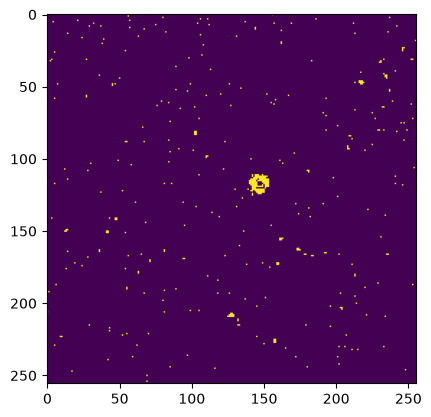

In [22]:
plt.imshow(bad&0b1111111111 != 0)

In [23]:
sci = fits.getdata('../data/NICMOS-LAPL-DD1/archive.stsci.edu/missions/hlsp/laplace/dd1/LAPL/NICMOS-LAPL-DD1/LAPL_DATA/contemp_flats/not_repaired/n4qs09akq_clc_cal.fits',1)

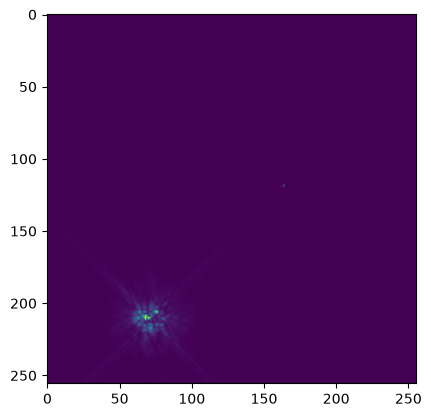

In [ ]:
plt.imshow(sci[])